# Brazo 1 — Frecuencia y módulo de Young

## Ajuste de la curva de anclaje a partir de Marshall et al.

Este notebook analiza los datos de módulo de Young obtenidos a partir de la frecuencia de resonancia de cantilevers MEMS reportados por Marshall et al.

Los objetivos principales son:

- cargar y validar las Tablas 1, 2, 3, 5 y 6 transcritas del artículo;
- describir la geometría, frecuencias de diseño e incertidumbres reportadas;
- reconstruir la desviación estándar a partir de los límites del 95 % de las Tablas 5 y 6;
- ajustar la curva de anclaje

$$
E(L) = E_{\mathrm{real}} \left(\frac{L}{L+\Delta L}\right)^4
$$

- estimar \(E_{\mathrm{real}}\) y \(\Delta L\) para repetibilidad y reproducibilidad;
- reportar intervalos de confianza del 95 %, residuos y gráficas del ajuste;
- documentar la limitación estadística del ajuste: tres longitudes y dos parámetros implican un solo grado de libertad.

> **Fuente primaria:** Marshall et al., *MEMS Young's Modulus and Step Height Measurements With Round Robin Results*, Journal of Research of NIST, 115(5), 303–342 (2010).


## Clonación de repositorio


In [1]:
# El notebook usa la misma estructura del proyecto y lee los Excel desde
# la rama feature/brazo1-EDA.

!git clone -b feature/brazo1-EDA https://github.com/isabellaarangor/proyecto-integrador-team39-MNA.git


Cloning into 'proyecto-integrador-team39-MNA'...
remote: Enumerating objects: 139, done.
remote: Counting objects: 100% (139/139), done.
remote: Compressing objects: 100% (128/128), done.
remote: Total 139 (delta 19), reused 106 (delta 6), pack-reused 0 (from 0)
Receiving objects: 100% (139/139), 826.38 KiB | 12.15 MiB/s, done.
Resolving deltas: 100% (19/19), done.


## Librerías


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import least_squares
from scipy.stats import t


## Estandarización de formatos


In [3]:
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

FIGSIZE = (10, 6)


## Extracción de archivos


In [4]:
REPO_DIR = Path("/content/proyecto-integrador-team39-MNA")
DATA_DIR = REPO_DIR / "datos" / "nist" / "crudos"

MARSHALL_FILES = {
    "table1": "02-Aa-Marshall-part-01-table1.xlsx",
    "table2": "02-Aa-Marshall-part-01-table2.xlsx",
    "table3": "02-Aa-Marshall-part-01-table3.xlsx",
    "table5": "02-Aa-Marshall-part-01-table5.xlsx",
    "table6": "02-Aa-Marshall-part-01-table6.xlsx",
}

SP260_FILES = {
    "table3": "nist-sp260-177-table3.xlsx",
}

for table_name, filename in MARSHALL_FILES.items():
    path = DATA_DIR / filename
    print(f"{table_name}: {path} | existe={path.exists()}")


for table_name, filename in SP260_FILES.items():
    path = DATA_DIR / filename
    print(f"SP 260-177 {table_name}: {path} | existe={path.exists()}")

table1: /content/proyecto-integrador-team39-MNA/datos/nist/crudos/02-Aa-Marshall-part-01-table1.xlsx | existe=True
table2: /content/proyecto-integrador-team39-MNA/datos/nist/crudos/02-Aa-Marshall-part-01-table2.xlsx | existe=True
table3: /content/proyecto-integrador-team39-MNA/datos/nist/crudos/02-Aa-Marshall-part-01-table3.xlsx | existe=True
table5: /content/proyecto-integrador-team39-MNA/datos/nist/crudos/02-Aa-Marshall-part-01-table5.xlsx | existe=True
table6: /content/proyecto-integrador-team39-MNA/datos/nist/crudos/02-Aa-Marshall-part-01-table6.xlsx | existe=True
SP 260-177 table3: /content/proyecto-integrador-team39-MNA/datos/nist/crudos/nist-sp260-177-table3.xlsx | existe=True


## Funciones para cargar y preparar las tablas


In [5]:
def load_marshall_table(table_name):
    """Carga una tabla de Marshall desde la carpeta de datos crudos."""
    if table_name not in MARSHALL_FILES:
        raise ValueError(
            f"Tabla desconocida: {table_name}. "
            f"Disponibles: {list(MARSHALL_FILES)}"
        )

    path = DATA_DIR / MARSHALL_FILES[table_name]

    if not path.exists():
        raise FileNotFoundError(f"No se encontró el archivo: {path}")

    return pd.read_excel(path)


def parse_percentage(value):
    """Convierte valores como '± 1.4%' a 1.4."""
    return float(
        str(value)
        .replace("±", "")
        .replace("%", "")
        .strip()
    )


def prepare_young_modulus_data(table):
    """Transforma las Tablas 5/6 al formato requerido para el ajuste."""
    lengths = [200, 300, 400]
    rows = []

    for L in lengths:
        column = f"{L} µm length"

        n = float(
            table.loc[table["Variable"] == "n", column].iloc[0]
        )
        E_mean = float(
            table.loc[table["Variable"] == "E_ave (GPa)", column].iloc[0]
        )
        limits_95_pct = parse_percentage(
            table.loc[table["Variable"] == "95% limits for E", column].iloc[0]
        )

        rows.append({
            "L_um": float(L),
            "n": int(n),
            "E_mean_GPa": E_mean,
            "limits_95_pct": limits_95_pct,
        })

    return pd.DataFrame(rows)


def add_uncertainties(df):
    """Reconstruye s y SE a partir de los límites del 95 % reportados."""
    result = df.copy()

    # Marshall: límite 95 % = 2*s, expresado como porcentaje de E_ave.
    result["std_GPa"] = (
        (result["limits_95_pct"] / 100.0)
        * result["E_mean_GPa"]
        / 2.0
    )

    # El ajuste se realiza sobre promedios; se usa el error estándar.
    result["se_GPa"] = (
        result["std_GPa"] / np.sqrt(result["n"])
    )

    return result


def load_sp260_table(table_name):
    """Carga una tabla de NIST SP 260-177 desde la carpeta de datos crudos."""
    if table_name not in SP260_FILES:
        raise ValueError(
            f"Tabla desconocida: {table_name}. "
            f"Disponibles: {list(SP260_FILES)}"
        )

    path = DATA_DIR / SP260_FILES[table_name]
    if not path.exists():
        raise FileNotFoundError(f"No se encontró el archivo: {path}")

    df = pd.read_excel(path)
    # Normaliza el signo menos Unicode si Excel lo leyó como texto.
    for col in df.columns:
        if df[col].dtype == "object":
            df[col] = df[col].map(
                lambda x: x.replace("−", "-") if isinstance(x, str) else x
            )
    return df


## Carga de las tablas


In [6]:
table1 = load_marshall_table("table1")
table2 = load_marshall_table("table2")
table3 = load_marshall_table("table3")
table5 = load_marshall_table("table5")
table6 = load_marshall_table("table6")

sp260_table3 = load_sp260_table("table3")

## Validación de la carga de datos


In [7]:
for name, table in {
    "Tabla 1": table1,
    "Tabla 2": table2,
    "Tabla 3": table3,
    "Tabla 5": table5,
    "Tabla 6": table6,
}.items():
    print("\n" + "=" * 80)
    print(name)
    print("Shape:", table.shape)
    print("Columnas:", list(table.columns))
    display(table)



Tabla 1
Shape: (5, 5)
Columnas: ['L_um', 'W_um', 'orientation_deg', 'material', 'n_cantilevers']


,L_um,W_um,orientation_deg,material,n_cantilevers
0,200,28,0,oxide,5
1,248,28,0,oxide,5
2,300,28,0,oxide,5
3,348,28,0,oxide,5
4,400,28,0,oxide,5



Tabla 2
Shape: (5, 4)
Columnas: ['L µm', 'f inicial kHz', 'Q', 'pdiff %']


,L µm,f inicial kHz,Q,pdiff %
0,200,62.5000,148.0000,0.0006
1,248,40.6000,96.3000,0.0013
2,300,27.8000,65.8000,0.0029
3,348,20.6000,48.9000,0.0052
4,400,15.6000,37.0000,0.0091



Tabla 3
Shape: (8, 2)
Columnas: ['componente', 'GPa']


,componente,GPa
0,u_thick,2.8000
1,u_rho,1.5000
2,u_L,0.1700
3,u_freq,0.0270
4,u_fresol,0.0018
5,u_damp,0.0004
6,u_cE,3.2000
7,3u_cE,9.5000



Tabla 5
Shape: (5, 5)
Columnas: ['Variable', '200 µm length', '300 µm length', '400 µm length', '200 µm to 400 µm lengths']


,Variable,200 µm length,300 µm length,400 µm length,200 µm to 400 µm lengths
0,n,16,16,16,48
1,E_ave (GPa),59.8000,65.4000,67.5000,64.2000
2,95% limits for E,± 1.4%,± 0.5%,± 1.1%,± 10.3%
3,u_cave (GPa),2.9 (4.9%),3.2 (4.8%),3.3 (4.8%),3.1 (4.8%)
4,95% limits for u_cE,± 1.4%,± 0.5%,± 1.1%,± 10.1%



Tabla 6
Shape: (5, 5)
Columnas: ['Variable', '200 µm length', '300 µm length', '400 µm length', '200 µm to 400 µm lengths']


,Variable,200 µm length,300 µm length,400 µm length,200 µm to 400 µm lengths
0,n,8,8,8,24
1,E_ave (GPa),58.7000,63.7000,66,62.8000
2,95% limits for E,± 4.4%,± 5.5%,± 4.4%,± 11.0%
3,u_cave (GPa),2.8 (4.9%),3.1 (4.8%),3.2 (4.9%),3.0 (4.9%)
4,95% limits for u_cE,± 4.4%,± 5.5%,± 4.5%,± 11.0%


### NIST SP 260-177 — Tabla 3 (RM 8096)

La Tabla 3 se conserva como **fuente externa de comparación**. Corresponde al mismo sistema RM 8096 asociado con los cantilevers de óxido analizados en Marshall. Sus columnas relevantes son `f_correction`, `sigma_support` y `sigma_cantilever`.

**Importante:** `f_correction` no se aplica a los datos de Marshall. Se utiliza únicamente para comparar, después del ajuste, si la dependencia con la longitud inferida mediante \(\Delta L\) tiene una magnitud y un patrón compatibles con la corrección reportada por NIST.

In [8]:
display(sp260_table3)

assert set(sp260_table3["L (µm)"].astype(float)) == {200.0, 300.0, 400.0}
for col in ["f_correction (kHz)", "sigma_support (kHz)", "sigma_cantilever (kHz)"]:
    sp260_table3[col] = pd.to_numeric(sp260_table3[col], errors="raise")

# Verificación de la relación indicada en la tabla: sigma = |f_correction|/(3*sqrt(2)).
sp260_check = sp260_table3.copy()
sp260_check["sigma_from_f_correction_kHz"] = (
    sp260_check["f_correction (kHz)"].abs() / (3 * np.sqrt(2))
)
sp260_check["difference_support_kHz"] = (
    sp260_check["sigma_support (kHz)"]
    - sp260_check["sigma_from_f_correction_kHz"]
)
display(sp260_check)

,L (µm),f_correction (kHz),sigma_support (kHz),sigma_cantilever (kHz)
0,200,2.6700,0.6300,0.6300
1,300,0,0.0000,0.0000
2,400,-0.240,0.0570,0.0570


,L (µm),f_correction (kHz),sigma_support (kHz),sigma_cantilever (kHz),sigma_from_f_correction_kHz,difference_support_kHz
0,200,2.6700,0.6300,0.6300,0.6293,0.0007
1,300,0.0000,0.0000,0.0000,0.0000,0.0000
2,400,-0.2400,0.0570,0.0570,0.0566,0.0004


## 1. Estructura y comprensión de los datos

Las cinco tablas cumplen funciones diferentes dentro del Brazo 1:

- **Tabla 1:** geometría nominal de los cantilevers. Incluye cinco longitudes de diseño, ancho, orientación, material y cantidad de cantilevers.
- **Tabla 2:** frecuencia fundamental de diseño, factor de calidad \(Q\) y diferencia porcentual asociada al amortiguamiento para cada longitud.
- **Tabla 3:** ejemplo del presupuesto de incertidumbre del módulo de Young.
- **Tabla 5:** resultados de **repetibilidad**, con 16 valores de \(E\) para cada una de las longitudes 200, 300 y 400 µm.
- **Tabla 6:** resultados de **reproducibilidad**, con 8 valores de \(E\) para cada una de esas tres longitudes.

Las tablas se mantienen completas en `datos/nist/crudos/`. En el ajuste solo se seleccionan las tres longitudes individuales de las Tablas 5 y 6. La columna agregada `200 µm to 400 µm lengths` se conserva como información de la fuente, pero **no representa una cuarta longitud experimental** y no se utiliza como observación independiente.


### Geometría — Tabla 1


In [9]:
display(table1)


,L_um,W_um,orientation_deg,material,n_cantilevers
0,200,28,0,oxide,5
1,248,28,0,oxide,5
2,300,28,0,oxide,5
3,348,28,0,oxide,5
4,400,28,0,oxide,5


### Frecuencia de diseño y factor Q — Tabla 2


In [10]:
display(table2.describe(include="all").T)


,count,mean,std,min,25%,50%,75%,max
L µm,5.0000,299.2000,79.0645,200.0000,248.0000,300.0000,348.0000,400.0000
f inicial kHz,5.0000,33.4200,18.7796,15.6000,20.6000,27.8000,40.6000,62.5000
Q,5.0000,79.2000,44.4532,37.0000,48.9000,65.8000,96.3000,148.0000
pdiff %,5.0000,0.0038,0.0034,0.0006,0.0013,0.0029,0.0052,0.0091


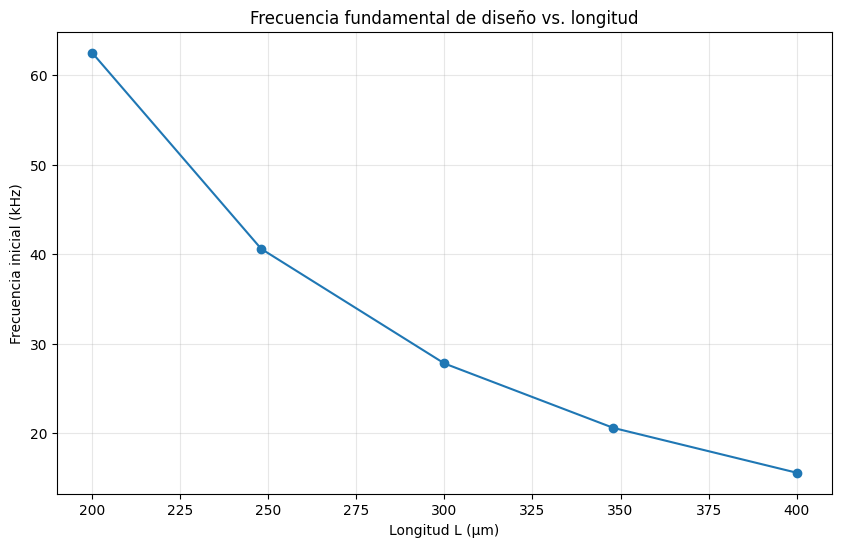

In [11]:
plt.figure(figsize=FIGSIZE)
plt.plot(table2["L µm"], table2["f inicial kHz"], marker="o")
plt.title("Frecuencia fundamental de diseño vs. longitud")
plt.xlabel("Longitud L (µm)")
plt.ylabel("Frecuencia inicial (kHz)")
plt.grid(alpha=0.3)
plt.show()


La frecuencia de diseño disminuye al aumentar la longitud del cantilever. Esta relación es coherente con la ecuación de resonancia utilizada por Marshall, en la que, manteniendo constantes las demás propiedades, la frecuencia fundamental depende inversamente de \(L^2\).


### Presupuesto de incertidumbre — Tabla 3


,componente,GPa
0,u_thick,2.8000
1,u_rho,1.5000
2,u_L,0.1700
3,u_freq,0.0270
4,u_fresol,0.0018
5,u_damp,0.0004
6,u_cE,3.2000
7,3u_cE,9.5000


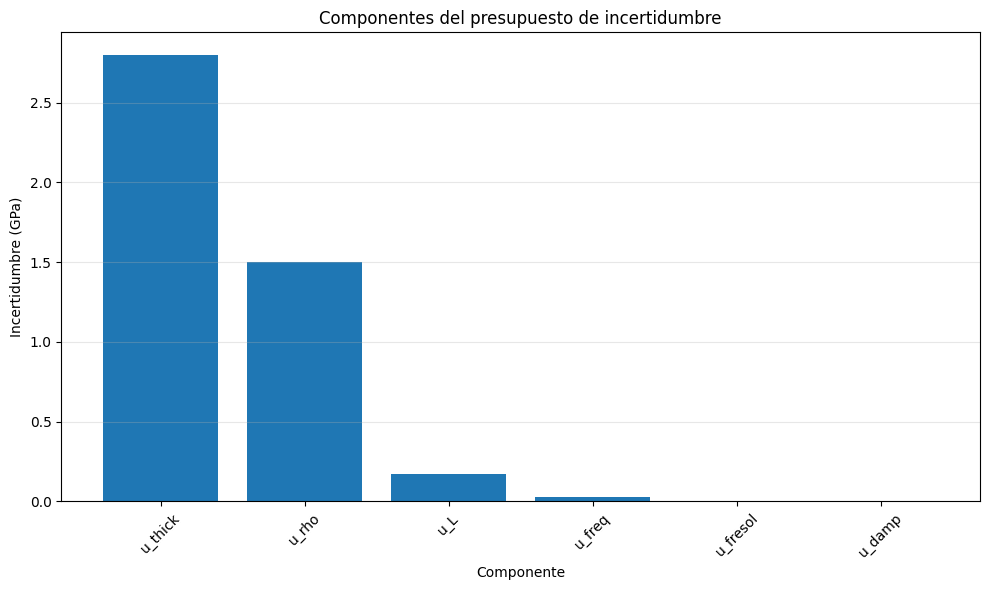

In [12]:
uncertainty_components = table3.loc[
    ~table3["componente"].isin(["u_cE", "3u_cE"])
].copy()

display(table3)

plt.figure(figsize=FIGSIZE)
plt.bar(uncertainty_components["componente"], uncertainty_components["GPa"])
plt.title("Componentes del presupuesto de incertidumbre")
plt.xlabel("Componente")
plt.ylabel("Incertidumbre (GPa)")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


La Tabla 3 muestra que, en el ejemplo de Marshall, la incertidumbre asociada al espesor y a la densidad domina el presupuesto frente a las contribuciones de longitud, frecuencia, resolución y amortiguamiento. Estos componentes ya forman parte de la incertidumbre combinada \(u_{cE}\); por ello, el parámetro \(\Delta L\) del ajuste no debe interpretarse simplemente como otra forma de esas incertidumbres instrumentales.


## 2. Preparación de los datos de repetibilidad y reproducibilidad


### Tabla 5 — Repetibilidad


In [13]:
display(table5)


,Variable,200 µm length,300 µm length,400 µm length,200 µm to 400 µm lengths
0,n,16,16,16,48
1,E_ave (GPa),59.8000,65.4000,67.5000,64.2000
2,95% limits for E,± 1.4%,± 0.5%,± 1.1%,± 10.3%
3,u_cave (GPa),2.9 (4.9%),3.2 (4.8%),3.3 (4.8%),3.1 (4.8%)
4,95% limits for u_cE,± 1.4%,± 0.5%,± 1.1%,± 10.1%


### Tabla 6 — Reproducibilidad


In [14]:
display(table6)


,Variable,200 µm length,300 µm length,400 µm length,200 µm to 400 µm lengths
0,n,8,8,8,24
1,E_ave (GPa),58.7000,63.7000,66,62.8000
2,95% limits for E,± 4.4%,± 5.5%,± 4.4%,± 11.0%
3,u_cave (GPa),2.8 (4.9%),3.1 (4.8%),3.2 (4.9%),3.0 (4.9%)
4,95% limits for u_cE,± 4.4%,± 5.5%,± 4.5%,± 11.0%


### Selección de las longitudes utilizadas en el ajuste


In [15]:
repeatability = prepare_young_modulus_data(table5)
reproducibility = prepare_young_modulus_data(table6)

display(repeatability)
display(reproducibility)


,L_um,n,E_mean_GPa,limits_95_pct
0,200.0000,16,59.8000,1.4000
1,300.0000,16,65.4000,0.5000
2,400.0000,16,67.5000,1.1000


,L_um,n,E_mean_GPa,limits_95_pct
0,200.0000,8,58.7000,4.4000
1,300.0000,8,63.7000,5.5000
2,400.0000,8,66.0000,4.4000


### Reconstrucción de la desviación estándar y del error estándar

Marshall reporta los límites del 95 % de \(E\) como dos veces la desviación estándar, expresada como porcentaje del promedio:

\[
p_{95}=100\frac{2s}{\bar E}.
\]

Por tanto,

\[
s=\frac{p_{95}}{100}\frac{\bar E}{2}.
\]

Como el ajuste solicitado utiliza los **promedios** por longitud, el análisis principal pondera cada punto con el error estándar:

\[
SE=\frac{s}{\sqrt{n}}.
\]

Esta transformación se realiza de forma programática a partir de los Excel originales; no se introducen manualmente los valores derivados.

> **Nota metodológica.** En la Tabla 5, \(n=16\) en las tres longitudes, y en la Tabla 6, \(n=8\) en las tres longitudes. Por tanto, pasar de \(s\) a \(SE\) multiplica todas las incertidumbres de un mismo ajuste por una constante. Esto no cambia los valores óptimos de \(E_{\mathrm{real}}\) ni \(\Delta L\), pero sí cambia la escala de los residuos ponderados y, por tanto, la interpretación del goodness-of-fit. Más adelante se incluye un análisis de sensibilidad `SE` vs. `SD`.

In [16]:
repeatability = add_uncertainties(repeatability)
reproducibility = add_uncertainties(reproducibility)

print("Repetibilidad")
display(repeatability)

print("Reproducibilidad")
display(reproducibility)


Repetibilidad


,L_um,n,E_mean_GPa,limits_95_pct,std_GPa,se_GPa
0,200.0000,16,59.8000,1.4000,0.4186,0.1046
1,300.0000,16,65.4000,0.5000,0.1635,0.0409
2,400.0000,16,67.5000,1.1000,0.3713,0.0928


Reproducibilidad


,L_um,n,E_mean_GPa,limits_95_pct,std_GPa,se_GPa
0,200.0000,8,58.7000,4.4000,1.2914,0.4566
1,300.0000,8,63.7000,5.5000,1.7518,0.6193
2,400.0000,8,66.0000,4.4000,1.4520,0.5134


### Comparación descriptiva de E por longitud


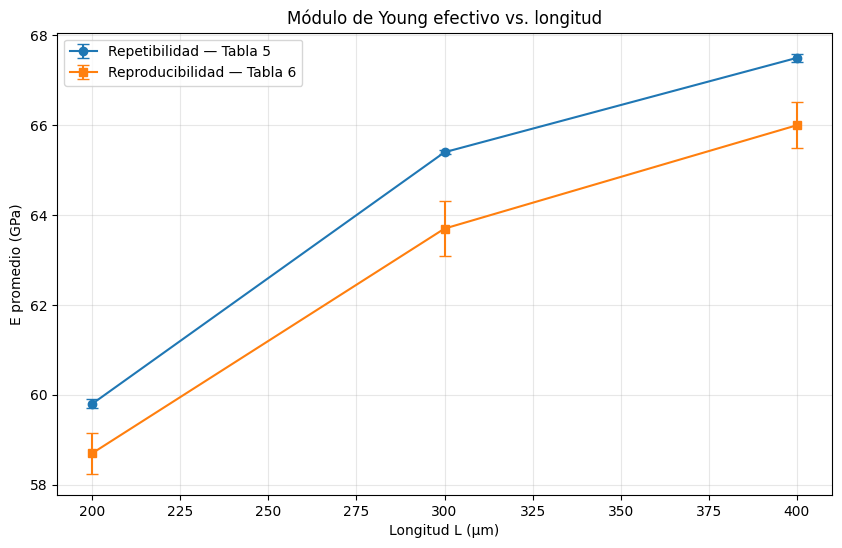

In [17]:
plt.figure(figsize=FIGSIZE)

plt.errorbar(
    repeatability["L_um"],
    repeatability["E_mean_GPa"],
    yerr=repeatability["se_GPa"],
    marker="o",
    capsize=4,
    label="Repetibilidad — Tabla 5",
)

plt.errorbar(
    reproducibility["L_um"],
    reproducibility["E_mean_GPa"],
    yerr=reproducibility["se_GPa"],
    marker="s",
    capsize=4,
    label="Reproducibilidad — Tabla 6",
)

plt.title("Módulo de Young efectivo vs. longitud")
plt.xlabel("Longitud L (µm)")
plt.ylabel("E promedio (GPa)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


En ambos conjuntos se observa la misma tendencia descriptiva: el módulo de Young efectivo aumenta con la longitud nominal del cantilever. El ajuste siguiente evalúa si esa tendencia es compatible con una corrección efectiva de longitud.


## 3. Ajuste de la curva de anclaje


### Modelo

Se utiliza el modelo:

\[
E(L)=E_{\mathrm{real}}\left(\frac{L}{L+\Delta L}\right)^4,
\]

donde:

- \(E_{\mathrm{real}}\) es el módulo de Young estimado del material;
- \(\Delta L\) es una corrección efectiva de longitud asociada al comportamiento del anclaje;
- \(L\) es la longitud nominal del cantilever.

La potencia cuatro está motivada por la ecuación de Marshall para un cantilever resonante:

\[
E=\frac{38.330\,\rho\,f_{\mathrm{can}}^2L_{\mathrm{can}}^4}{t^2}.
\]

El ajuste se realiza mediante mínimos cuadrados no lineales ponderados usando `scipy.optimize.least_squares`.


In [18]:
def anchoring_model(L, E_real, delta_L):
    """Modelo de corrección efectiva de longitud."""
    L = np.asarray(L, dtype=float)
    return E_real * (L / (L + delta_L)) ** 4


def weighted_residuals(params, L, E_obs, sigma):
    """Residuos ponderados por el error estándar de cada promedio."""
    E_real, delta_L = params
    E_pred = anchoring_model(L, E_real, delta_L)
    return (E_obs - E_pred) / sigma


### Función de ajuste e intervalos de confianza


In [19]:
def fit_anchoring_curve(df, uncertainty="se_GPa", initial_guess=(70.0, 5.0)):
    """Ajusta la curva y calcula diagnósticos e IC 95 % aproximados.

    Parameters
    ----------
    df : pandas.DataFrame
        Datos preparados por longitud.
    uncertainty : {"se_GPa", "std_GPa"}
        Columna utilizada para ponderar los residuos.
        El análisis principal usa ``se_GPa`` según la consigna.
    initial_guess : tuple
        Valores iniciales (E_real, delta_L).
    """
    if uncertainty not in {"se_GPa", "std_GPa"}:
        raise ValueError("uncertainty debe ser 'se_GPa' o 'std_GPa'")

    L = df["L_um"].to_numpy(dtype=float)
    E_obs = df["E_mean_GPa"].to_numpy(dtype=float)
    sigma = df[uncertainty].to_numpy(dtype=float)

    result = least_squares(
        weighted_residuals,
        x0=np.asarray(initial_guess, dtype=float),
        args=(L, E_obs, sigma),
        bounds=([0.0, 0.0], [np.inf, np.inf]),
    )

    E_real, delta_L = result.x
    E_pred = anchoring_model(L, E_real, delta_L)

    n_obs = len(L)
    n_params = len(result.x)
    dof = n_obs - n_params

    weighted_rss = np.sum(result.fun ** 2)
    wrss_per_df = weighted_rss / dof

    # Covarianza aproximada a partir de la linealización local del modelo.
    # Con df=1, estos IC son frágiles y deben interpretarse solo como aproximados.
    jtj = result.jac.T @ result.jac
    cov = np.linalg.pinv(jtj) * (weighted_rss / dof)
    parameter_se = np.sqrt(np.diag(cov))

    t_crit = t.ppf(0.975, df=dof)

    E_real_ci95 = (
        E_real - t_crit * parameter_se[0],
        E_real + t_crit * parameter_se[0],
    )
    delta_L_ci95 = (
        delta_L - t_crit * parameter_se[1],
        delta_L + t_crit * parameter_se[1],
    )

    residuals = df.copy()
    residuals["E_pred_GPa"] = E_pred
    residuals["residual_GPa"] = residuals["E_mean_GPa"] - E_pred
    residuals["fit_sigma_GPa"] = sigma
    residuals["standardized_residual"] = residuals["residual_GPa"] / sigma

    return {
        "optimizer": result,
        "uncertainty": uncertainty,
        "E_real_GPa": E_real,
        "E_real_se_GPa": parameter_se[0],
        "E_real_ci95": E_real_ci95,
        "delta_L_um": delta_L,
        "delta_L_se_um": parameter_se[1],
        "delta_L_ci95": delta_L_ci95,
        "dof": dof,
        "weighted_rss": weighted_rss,
        "wrss_per_df": wrss_per_df,
        "residuals": residuals,
    }


def print_fit_summary(name, fit):
    """Imprime un resumen compacto del ajuste."""
    print(name)
    print("-" * len(name))
    print(f"Ponderación = {fit['uncertainty']}")
    print(
        f"E_real = {fit['E_real_GPa']:.4f} GPa "
        f"(IC 95 % aprox.: {fit['E_real_ci95'][0]:.4f}, "
        f"{fit['E_real_ci95'][1]:.4f})"
    )
    print(
        f"Delta L = {fit['delta_L_um']:.4f} µm "
        f"(IC 95 % aprox.: {fit['delta_L_ci95'][0]:.4f}, "
        f"{fit['delta_L_ci95'][1]:.4f})"
    )
    print(f"Grados de libertad = {fit['dof']}")
    print(f"WRSS = {fit['weighted_rss']:.4f}")
    print(f"WRSS / df = {fit['wrss_per_df']:.4f}")

### Ajuste — repetibilidad (Tabla 5)


In [20]:
fit_repeatability = fit_anchoring_curve(repeatability, uncertainty="se_GPa")
print_fit_summary("Repetibilidad — Tabla 5", fit_repeatability)

Repetibilidad — Tabla 5
-----------------------
Ponderación = se_GPa
E_real = 77.1358 GPa (IC 95 % aprox.: 54.3407, 99.9310)
Delta L = 12.8180 µm (IC 95 % aprox.: -9.7856, 35.4215)
Grados de libertad = 1
WRSS = 53.9593
WRSS / df = 53.9593


#### Residuos — repetibilidad


In [21]:
display(fit_repeatability["residuals"])


,L_um,n,E_mean_GPa,limits_95_pct,std_GPa,se_GPa,E_pred_GPa,residual_GPa,fit_sigma_GPa,standardized_residual
0,200.0000,16,59.8000,1.4000,0.4186,0.1046,60.1649,-0.3649,0.1046,-3.4868
1,300.0000,16,65.4000,0.5000,0.1635,0.0409,65.2491,0.1509,0.0409,3.6917
2,400.0000,16,67.5000,1.1000,0.3713,0.0928,67.9926,-0.4926,0.0928,-5.3079


#### Curva ajustada — repetibilidad


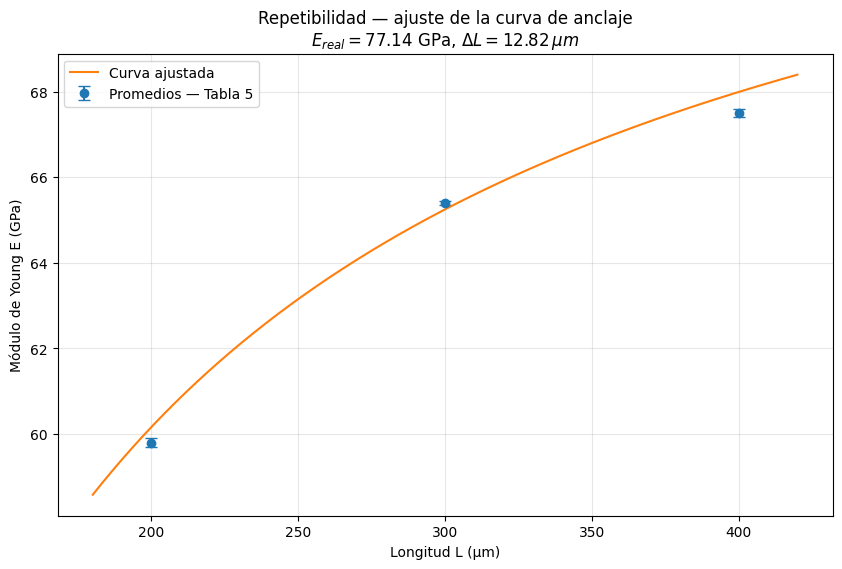

In [22]:
L_curve = np.linspace(180, 420, 400)

plt.figure(figsize=FIGSIZE)
plt.errorbar(
    repeatability["L_um"],
    repeatability["E_mean_GPa"],
    yerr=repeatability["se_GPa"],
    fmt="o",
    capsize=4,
    label="Promedios — Tabla 5",
)
plt.plot(
    L_curve,
    anchoring_model(
        L_curve,
        fit_repeatability["E_real_GPa"],
        fit_repeatability["delta_L_um"],
    ),
    label="Curva ajustada",
)
plt.title(
    "Repetibilidad — ajuste de la curva de anclaje\n"
    rf"$E_{{real}}={fit_repeatability['E_real_GPa']:.2f}$ GPa, "
    rf"$\Delta L={fit_repeatability['delta_L_um']:.2f}\,\mu m$"
)
plt.xlabel("Longitud L (µm)")
plt.ylabel("Módulo de Young E (GPa)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


### Ajuste — reproducibilidad (Tabla 6)


In [23]:
fit_reproducibility = fit_anchoring_curve(reproducibility, uncertainty="se_GPa")
print_fit_summary("Reproducibilidad — Tabla 6", fit_reproducibility)

Reproducibilidad — Tabla 6
--------------------------
Ponderación = se_GPa
E_real = 74.6107 GPa (IC 95 % aprox.: 68.8670, 80.3545)
Delta L = 12.3252 µm (IC 95 % aprox.: 7.0112, 17.6391)
Grados de libertad = 1
WRSS = 0.1239
WRSS / df = 0.1239


#### Residuos — reproducibilidad


In [24]:
display(fit_reproducibility["residuals"])


,L_um,n,E_mean_GPa,limits_95_pct,std_GPa,se_GPa,E_pred_GPa,residual_GPa,fit_sigma_GPa,standardized_residual
0,200.0000,8,58.7000,4.4000,1.2914,0.4566,58.7375,-0.0375,0.4566,-0.0821
1,300.0000,8,63.7000,5.5000,1.7518,0.6193,63.5124,0.1876,0.6193,0.3030
2,400.0000,8,66.0000,4.4000,1.4520,0.5134,66.0818,-0.0818,0.5134,-0.1593


#### Curva ajustada — reproducibilidad


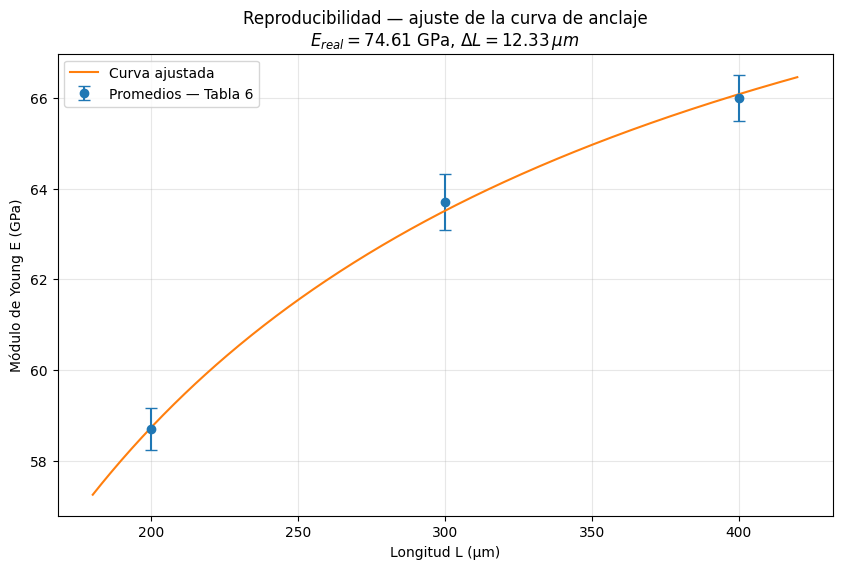

In [25]:
plt.figure(figsize=FIGSIZE)
plt.errorbar(
    reproducibility["L_um"],
    reproducibility["E_mean_GPa"],
    yerr=reproducibility["se_GPa"],
    fmt="o",
    capsize=4,
    label="Promedios — Tabla 6",
)
plt.plot(
    L_curve,
    anchoring_model(
        L_curve,
        fit_reproducibility["E_real_GPa"],
        fit_reproducibility["delta_L_um"],
    ),
    label="Curva ajustada",
)
plt.title(
    "Reproducibilidad — ajuste de la curva de anclaje\n"
    rf"$E_{{real}}={fit_reproducibility['E_real_GPa']:.2f}$ GPa, "
    rf"$\Delta L={fit_reproducibility['delta_L_um']:.2f}\,\mu m$"
)
plt.xlabel("Longitud L (µm)")
plt.ylabel("Módulo de Young E (GPa)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


### Comparación de los dos ajustes


In [26]:
fit_summary = pd.DataFrame([
    {
        "dataset": "Repetibilidad — Tabla 5",
        "E_real_GPa": fit_repeatability["E_real_GPa"],
        "E_real_CI95_low": fit_repeatability["E_real_ci95"][0],
        "E_real_CI95_high": fit_repeatability["E_real_ci95"][1],
        "delta_L_um": fit_repeatability["delta_L_um"],
        "delta_L_CI95_low": fit_repeatability["delta_L_ci95"][0],
        "delta_L_CI95_high": fit_repeatability["delta_L_ci95"][1],
        "dof": fit_repeatability["dof"],
        "weighted_rss": fit_repeatability["weighted_rss"],
        "weighted_rss_per_df": fit_repeatability["wrss_per_df"],
    },
    {
        "dataset": "Reproducibilidad — Tabla 6",
        "E_real_GPa": fit_reproducibility["E_real_GPa"],
        "E_real_CI95_low": fit_reproducibility["E_real_ci95"][0],
        "E_real_CI95_high": fit_reproducibility["E_real_ci95"][1],
        "delta_L_um": fit_reproducibility["delta_L_um"],
        "delta_L_CI95_low": fit_reproducibility["delta_L_ci95"][0],
        "delta_L_CI95_high": fit_reproducibility["delta_L_ci95"][1],
        "dof": fit_reproducibility["dof"],
        "weighted_rss": fit_reproducibility["weighted_rss"],
        "weighted_rss_per_df": fit_reproducibility["wrss_per_df"],
    },
])

display(fit_summary)


,dataset,E_real_GPa,E_real_CI95_low,E_real_CI95_high,delta_L_um,delta_L_CI95_low,delta_L_CI95_high,dof,weighted_rss,weighted_rss_per_df
0,Repetibilidad — Tabla 5,77.1358,54.3407,99.9310,12.8180,-9.7856,35.4215,1,53.9593,53.9593
1,Reproducibilidad — Tabla 6,74.6107,68.8670,80.3545,12.3252,7.0112,17.6391,1,0.1239,0.1239


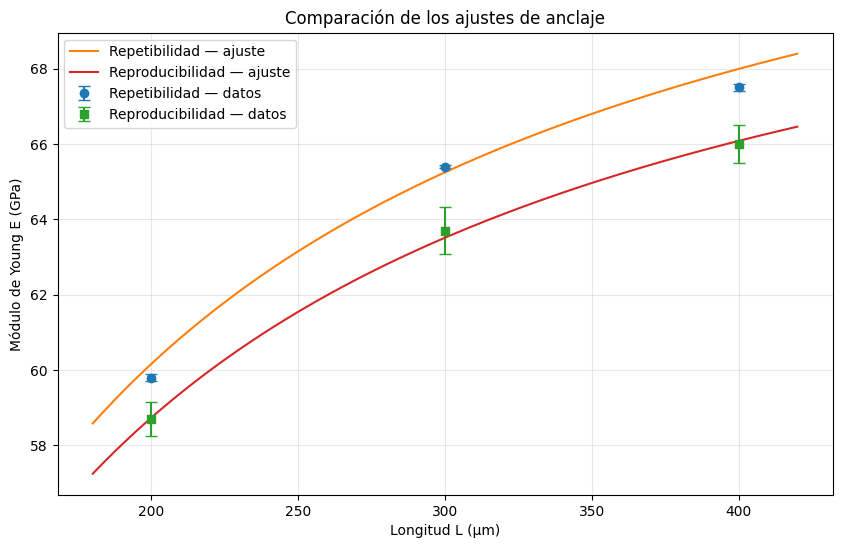

In [27]:
plt.figure(figsize=FIGSIZE)

plt.errorbar(
    repeatability["L_um"],
    repeatability["E_mean_GPa"],
    yerr=repeatability["se_GPa"],
    fmt="o",
    capsize=4,
    label="Repetibilidad — datos",
)
plt.plot(
    L_curve,
    anchoring_model(
        L_curve,
        fit_repeatability["E_real_GPa"],
        fit_repeatability["delta_L_um"],
    ),
    label="Repetibilidad — ajuste",
)

plt.errorbar(
    reproducibility["L_um"],
    reproducibility["E_mean_GPa"],
    yerr=reproducibility["se_GPa"],
    fmt="s",
    capsize=4,
    label="Reproducibilidad — datos",
)
plt.plot(
    L_curve,
    anchoring_model(
        L_curve,
        fit_reproducibility["E_real_GPa"],
        fit_reproducibility["delta_L_um"],
    ),
    label="Reproducibilidad — ajuste",
)

plt.title("Comparación de los ajustes de anclaje")
plt.xlabel("Longitud L (µm)")
plt.ylabel("Módulo de Young E (GPa)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


### Interpretación del ajuste

Los dos conjuntos producen estimaciones centrales muy similares de la corrección efectiva de longitud: aproximadamente \(12\text{–}13\,\mu\mathrm{m}\). Como referencia de control, el ajuste exploratorio previo reportó valores del orden de \(\Delta L\approx 12\text{–}13\,\mu\mathrm{m}\) y \(E_{\mathrm{real}}\approx75\text{–}77\,\mathrm{GPa}\). Esa referencia se utiliza únicamente como comparación y **no se impone como restricción al optimizador**.

Sin embargo, la similitud de los parámetros no implica que la calidad del ajuste sea igual en ambos conjuntos. Con la ponderación principal basada en el error estándar, la repetibilidad presenta discrepancias grandes respecto a la pequeña incertidumbre estadística de sus medias, mientras que la reproducibilidad queda mucho más cerca de la curva en unidades de su incertidumbre.

Los intervalos mostrados son **IC 95 % aproximados por linealización local**, obtenidos a partir del Jacobiano y una distribución t de Student. Con solo un grado de libertad, \(t_{0.975,1}\approx12.706\), por lo que estos intervalos son muy sensibles y no deben interpretarse como una caracterización precisa de la incertidumbre paramétrica.

> **Sobre el IC negativo de \(\Delta L\) en repetibilidad.** El optimizador impone \(\Delta L\ge 0\). El límite inferior negativo puede aparecer después porque el IC aproximado se construye de forma simétrica alrededor del estimador y no incorpora el `bound` del optimizador. No significa que el ajuste haya estimado una longitud efectiva negativa.

## 4. Diagnóstico de residuos


In [28]:
residual_comparison = pd.concat([
    fit_repeatability["residuals"].assign(dataset="Repetibilidad"),
    fit_reproducibility["residuals"].assign(dataset="Reproducibilidad"),
], ignore_index=True)

display(residual_comparison)


,L_um,n,E_mean_GPa,limits_95_pct,std_GPa,se_GPa,E_pred_GPa,residual_GPa,fit_sigma_GPa,standardized_residual,dataset
0,200.0000,16,59.8000,1.4000,0.4186,0.1046,60.1649,-0.3649,0.1046,-3.4868,Repetibilidad
1,300.0000,16,65.4000,0.5000,0.1635,0.0409,65.2491,0.1509,0.0409,3.6917,Repetibilidad
2,400.0000,16,67.5000,1.1000,0.3713,0.0928,67.9926,-0.4926,0.0928,-5.3079,Repetibilidad
3,200.0000,8,58.7000,4.4000,1.2914,0.4566,58.7375,-0.0375,0.4566,-0.0821,Reproducibilidad
4,300.0000,8,63.7000,5.5000,1.7518,0.6193,63.5124,0.1876,0.6193,0.3030,Reproducibilidad
5,400.0000,8,66.0000,4.4000,1.4520,0.5134,66.0818,-0.0818,0.5134,-0.1593,Reproducibilidad


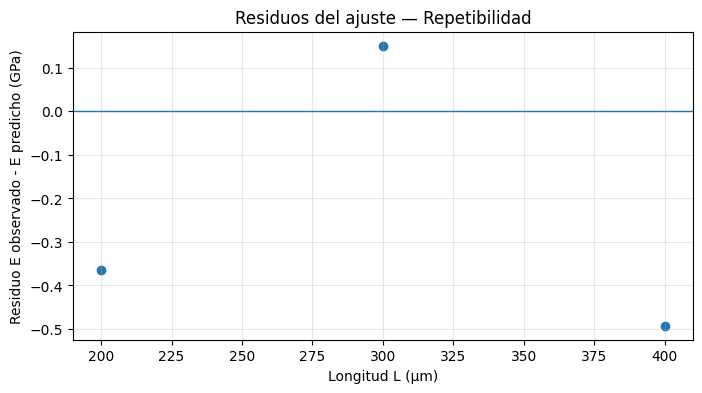

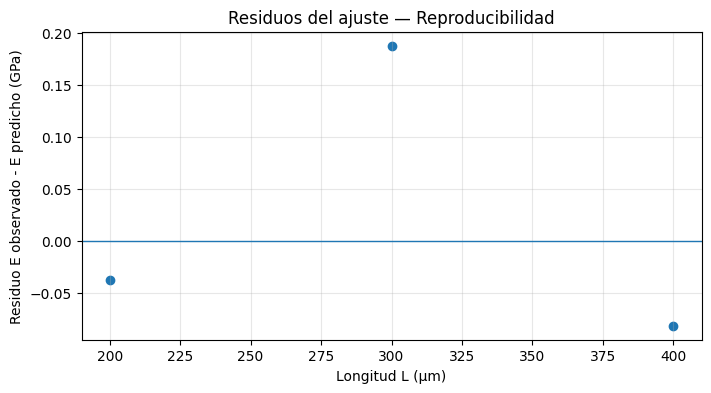

In [29]:
for dataset, group in residual_comparison.groupby("dataset"):
    plt.figure(figsize=(8, 4))
    plt.axhline(0, linewidth=1)
    plt.scatter(group["L_um"], group["residual_GPa"])
    plt.title(f"Residuos del ajuste — {dataset}")
    plt.xlabel("Longitud L (µm)")
    plt.ylabel("Residuo E observado - E predicho (GPa)")
    plt.grid(alpha=0.3)
    plt.show()


### Residuos estandarizados

Además del residuo en GPa, conviene inspeccionar el residuo dividido por la incertidumbre utilizada en el ajuste:

\[
r_i^{*}=\frac{E_{i,\mathrm{obs}}-E_{i,\mathrm{pred}}}{\sigma_i}.
\]

Con la ponderación principal, \(\sigma_i=SE_i\). Las líneas \(\pm2\) se muestran solo como referencia visual; con tres observaciones y un grado de libertad **no constituyen un test formal de adecuación del modelo**.

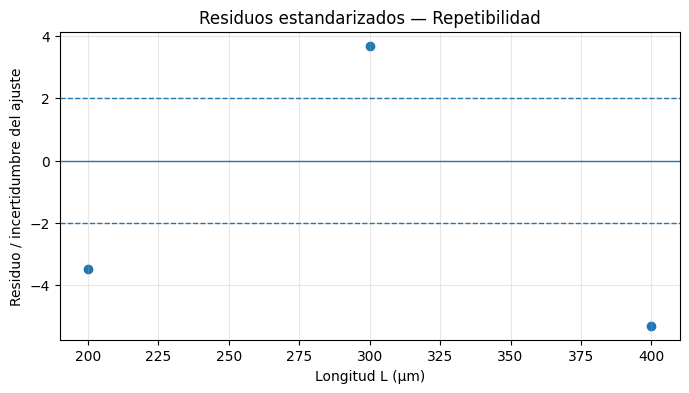

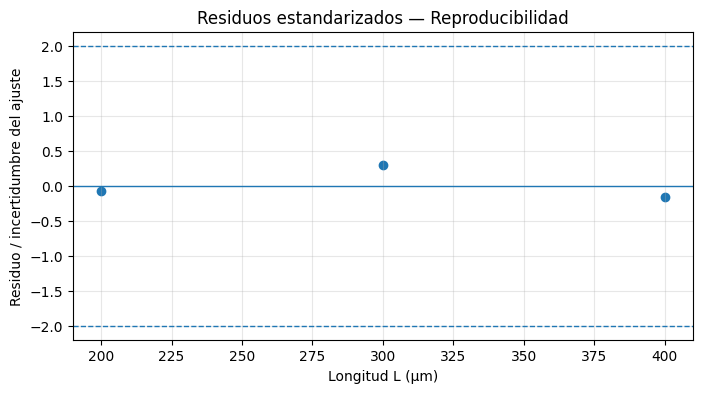

In [30]:
for dataset, group in residual_comparison.groupby("dataset"):
    plt.figure(figsize=(8, 4))
    plt.axhline(0, linewidth=1)
    plt.axhline(2, linestyle="--", linewidth=1)
    plt.axhline(-2, linestyle="--", linewidth=1)
    plt.scatter(group["L_um"], group["standardized_residual"])
    plt.title(f"Residuos estandarizados — {dataset}")
    plt.xlabel("Longitud L (µm)")
    plt.ylabel("Residuo / incertidumbre del ajuste")
    plt.grid(alpha=0.3)
    plt.show()

### Lectura de los residuos

- **Repetibilidad:** la curva captura la tendencia creciente de \(E\) con \(L\), pero los residuos estandarizados son grandes respecto a los errores estándar de los promedios. Por tanto, el modelo de dos parámetros no reproduce los tres promedios dentro de esa escala de incertidumbre tan pequeña.
- **Reproducibilidad:** los residuos estandarizados son mucho menores; la curva es compatible con los tres promedios a la escala de incertidumbre utilizada.

Esta diferencia es relevante: la estabilidad de \(\Delta L\) entre ambos experimentos es una observación útil, pero **no debe confundirse con evidencia de un ajuste igualmente bueno en repetibilidad y reproducibilidad**.

### Limitación del diagnóstico

Con solo tres observaciones por ajuste no es posible realizar un diagnóstico de residuos robusto ni evaluar de forma fiable normalidad, heterocedasticidad o estructura sistemática. Los residuos se reportan porque permiten inspeccionar la discrepancia puntual entre el modelo y cada promedio, no porque constituyan una muestra suficiente para validar estadísticamente el modelo.


## 5. Análisis de sensibilidad: ponderación con SE vs. SD

El análisis principal usa \(SE=s/\sqrt{n}\), tal como pide la consigna. Como comprobación metodológica, se repite el ajuste usando directamente la desviación estándar \(s\).

Esto permite separar dos preguntas:

1. **¿Cambia la estimación de \(E_{\mathrm{real}}\) o \(\Delta L\)?**
2. **¿Cambia la lectura del tamaño de los residuos respecto a la dispersión experimental?**

Como \(n\) es constante entre las tres longitudes dentro de cada tabla, cambiar de SE a SD solo reescala todos los pesos de ese ajuste por una misma constante. Por ello, los parámetros óptimos deben permanecer prácticamente iguales; lo que cambia es la escala del WRSS y de los residuos estandarizados.

In [31]:
fit_repeatability_sd = fit_anchoring_curve(repeatability, uncertainty="std_GPa")
fit_reproducibility_sd = fit_anchoring_curve(reproducibility, uncertainty="std_GPa")

sensitivity = pd.DataFrame([
    {
        "dataset": "Repetibilidad",
        "ponderacion": "SE",
        "E_real_GPa": fit_repeatability["E_real_GPa"],
        "delta_L_um": fit_repeatability["delta_L_um"],
        "WRSS": fit_repeatability["weighted_rss"],
        "WRSS_per_df": fit_repeatability["wrss_per_df"],
    },
    {
        "dataset": "Repetibilidad",
        "ponderacion": "SD",
        "E_real_GPa": fit_repeatability_sd["E_real_GPa"],
        "delta_L_um": fit_repeatability_sd["delta_L_um"],
        "WRSS": fit_repeatability_sd["weighted_rss"],
        "WRSS_per_df": fit_repeatability_sd["wrss_per_df"],
    },
    {
        "dataset": "Reproducibilidad",
        "ponderacion": "SE",
        "E_real_GPa": fit_reproducibility["E_real_GPa"],
        "delta_L_um": fit_reproducibility["delta_L_um"],
        "WRSS": fit_reproducibility["weighted_rss"],
        "WRSS_per_df": fit_reproducibility["wrss_per_df"],
    },
    {
        "dataset": "Reproducibilidad",
        "ponderacion": "SD",
        "E_real_GPa": fit_reproducibility_sd["E_real_GPa"],
        "delta_L_um": fit_reproducibility_sd["delta_L_um"],
        "WRSS": fit_reproducibility_sd["weighted_rss"],
        "WRSS_per_df": fit_reproducibility_sd["wrss_per_df"],
    },
])

display(sensitivity)

,dataset,ponderacion,E_real_GPa,delta_L_um,WRSS,WRSS_per_df
0,Repetibilidad,SE,77.1358,12.8180,53.9593,53.9593
1,Repetibilidad,SD,77.1358,12.8180,3.3725,3.3725
2,Reproducibilidad,SE,74.6107,12.3252,0.1239,0.1239
3,Reproducibilidad,SD,74.6107,12.3252,0.0155,0.0155


### Interpretación de la sensibilidad

Si los valores de \(E_{\mathrm{real}}\) y \(\Delta L\) coinciden entre SE y SD, no es una coincidencia: dentro de cada tabla todas las longitudes tienen el mismo \(n\), de modo que el cambio de ponderación es un reescalamiento uniforme.

El análisis principal se conserva con **SE**, porque es el procedimiento solicitado. El ajuste con **SD** se reporta únicamente como sensibilidad para mostrar que la estimación central de \(\Delta L\) no depende de ese reescalamiento, aunque la interpretación del tamaño de los residuos sí cambia.

## 6. Grados de libertad e identificabilidad


In [32]:
n_observations = len(repeatability)
n_parameters = 2
degrees_of_freedom = n_observations - n_parameters

print(f"Observaciones por ajuste: {n_observations}")
print(f"Parámetros estimados: {n_parameters}")
print(f"Grados de libertad: {degrees_of_freedom}")
print(f"t crítico (95 %, df=1): {t.ppf(0.975, df=degrees_of_freedom):.4f}")


Observaciones por ajuste: 3
Parámetros estimados: 2
Grados de libertad: 1
t crítico (95 %, df=1): 12.7062


Cada ajuste utiliza tres longitudes experimentales y estima dos parámetros:

\[
\nu=n-p=3-2=1.
\]

Por tanto, queda **un solo grado de libertad**. Esta es una limitación central del Brazo 1.

El ajuste puede estimar una magnitud efectiva de \(\Delta L\) y comprobar si la tendencia observada es compatible con el modelo propuesto. Sin embargo, **no permite demostrar que el anclaje sea la causa única de la dependencia con la longitud ni distinguir de manera sólida esta curva de otras curvas monótonas con dos parámetros**.


## 7. Utilidad posterior: reconstrucción de frecuencia a partir de E


Para etapas posteriores puede reconstruirse la frecuencia a partir del módulo de Young utilizando la Ec. 7 de Marshall:

\[
E=\frac{38.330\rho f^2L^4}{t^2},
\]

de donde

\[
f=\sqrt{\frac{Et^2}{38.330\rho L^4}}.
\]

Esta operación **no interviene en la estimación de \(\Delta L\) presentada en este notebook**. Se conserva como utilidad para transformar posteriormente el observable \(E\) a frecuencia usando la geometría nominal de la Tabla 1 y unidades coherentes.


In [33]:
def frequency_from_young_modulus(E, L, thickness, density):
    """Despeje algebraico de la Ec. 7 de Marshall.

    IMPORTANTE: E, L, thickness y density deben expresarse en un sistema
    de unidades coherente antes de usar esta función.
    """
    return np.sqrt(
        E * thickness**2
        / (38.330 * density * L**4)
    )


## 8. Comparación exploratoria de escala con NIST SP 260-177


La comparación se realiza con la **Tabla 3 de SP 260-177 (RM 8096)**. No se modifica ningún dato de Marshall con `f_correction`.

NIST toma el cantilever de **300 µm como referencia**, por lo que `f_correction = 0` en esa longitud. Para poner nuestro parámetro \(\Delta L\) en una escala comparable, se construye un **desplazamiento equivalente de frecuencia relativo a 300 µm**.

De la Ec. 7 de Marshall, \(E\propto f^2L^4\). Bajo el modelo de longitud efectiva, el factor asociado es

\[
g(L;\Delta L)=\left(\frac{L+\Delta L}{L}\right)^2.
\]

Tomando 300 µm como referencia:

\[
R(L)=\frac{g(L;\Delta L)}{g(300;\Delta L)},
\]

y usando la frecuencia de diseño de la Tabla 2 **solo como escala**:

\[
\Delta f_{eq}(L)=f_{design}(L)[R(L)-1].
\]

Esta transformación es una **comprobación exploratoria de escala y tendencia**. No constituye una validación independiente del modelo: \(\Delta L\) fue estimado precisamente a partir de la dependencia de \(E\) con \(L\), y la conversión posterior usa la misma relación física entre \(E\), \(f\) y \(L\). Además, las frecuencias de diseño se emplean como escala y no como frecuencias medidas del *round robin*.

Por tanto, la comparación permite preguntar si el signo y el orden de magnitud son compatibles con `f_correction`, pero **no demuestra que el anclaje sea el mecanismo causal**.


In [34]:
# Frecuencias de diseño para las tres longitudes usadas por SP 260-177.
f_design = (
    table2.rename(columns={"L µm": "L_um", "f inicial kHz": "f_design_kHz"})
    [["L_um", "f_design_kHz"]]
    .query("L_um in [200, 300, 400]")
    .copy()
)

sp_compare = (
    sp260_table3.rename(columns={
        "L (µm)": "L_um",
        "f_correction (kHz)": "f_correction_NIST_kHz",
        "sigma_support (kHz)": "sigma_support_NIST_kHz",
        "sigma_cantilever (kHz)": "sigma_cantilever_NIST_kHz",
    })
    .merge(f_design, on="L_um", how="left")
)

def equivalent_frequency_correction(L, f_design_kHz, delta_L_um, L_ref_um=300.0):
    """Convierte delta_L a corrección equivalente de frecuencia, anclada en L_ref."""
    L = np.asarray(L, dtype=float)
    f = np.asarray(f_design_kHz, dtype=float)
    g = ((L + delta_L_um) / L) ** 2
    g_ref = ((L_ref_um + delta_L_um) / L_ref_um) ** 2
    return f * (g / g_ref - 1.0)

for label, fit in [
    ("repeatability", fit_repeatability),
    ("reproducibility", fit_reproducibility),
]:
    sp_compare[f"f_equiv_{label}_kHz"] = equivalent_frequency_correction(
        sp_compare["L_um"],
        sp_compare["f_design_kHz"],
        fit["delta_L_um"],
    )
    sp_compare[f"error_{label}_kHz"] = (
        sp_compare[f"f_equiv_{label}_kHz"]
        - sp_compare["f_correction_NIST_kHz"]
    )

display(sp_compare.round(4))

,L_um,f_correction_NIST_kHz,sigma_support_NIST_kHz,sigma_cantilever_NIST_kHz,f_design_kHz,f_equiv_repeatability_kHz,error_repeatability_kHz,f_equiv_reproducibility_kHz,error_reproducibility_kHz
0,200,2.6700,0.6300,0.6300,62.5000,2.5872,-0.0828,2.4907,-0.1793
1,300,0.0000,0.0000,0.0000,27.8000,0.0000,0.0000,0.0000,0.0000
2,400,-0.2400,0.0570,0.0570,15.6000,-0.3180,-0.0780,-0.3063,-0.0663


### Lectura de la comparación

La comparación relevante es el **patrón por longitud** y el orden de magnitud. No se compara directamente \(\Delta L\) (µm) con `sigma_support` (kHz), porque son magnitudes físicas diferentes.

Con 300 µm como referencia, se espera observar:

1. una corrección positiva y mayor para 200 µm;
2. cero por construcción en 300 µm;
3. una corrección pequeña y negativa para 400 µm.

La proximidad entre \(\Delta f_{eq}\) y `f_correction` se interpreta únicamente como **consistencia exploratoria de escala y tendencia**. No es evidencia independiente ni permite identificar causalmente el anclaje.


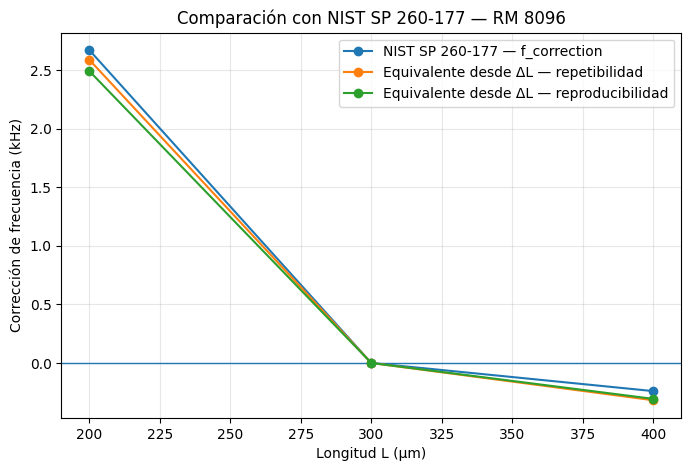

In [35]:
plt.figure(figsize=(8, 5))
plt.axhline(0, linewidth=1)
plt.plot(
    sp_compare["L_um"], sp_compare["f_correction_NIST_kHz"],
    marker="o", label="NIST SP 260-177 — f_correction"
)
plt.plot(
    sp_compare["L_um"], sp_compare["f_equiv_repeatability_kHz"],
    marker="o", label="Equivalente desde ΔL — repetibilidad"
)
plt.plot(
    sp_compare["L_um"], sp_compare["f_equiv_reproducibility_kHz"],
    marker="o", label="Equivalente desde ΔL — reproducibilidad"
)
plt.xlabel("Longitud L (µm)")
plt.ylabel("Corrección de frecuencia (kHz)")
plt.title("Comparación con NIST SP 260-177 — RM 8096")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [36]:
# Métrica descriptiva de proximidad; no es una prueba de validación estadística.
for label in ["repeatability", "reproducibility"]:
    error = sp_compare[f"error_{label}_kHz"].to_numpy(dtype=float)
    rmse = np.sqrt(np.mean(error**2))
    print(f"{label}: RMSE descriptivo frente a f_correction = {rmse:.4f} kHz")


repeatability: RMSE descriptivo frente a f_correction = 0.0657 kHz
reproducibility: RMSE descriptivo frente a f_correction = 0.1103 kHz


### `sigma_support`

`sigma_support` se conserva como referencia del presupuesto de incertidumbre asociado a soporte no ideal. En la Tabla 3 satisface aproximadamente

\[
\sigma_{support}=\frac{|f_{correction}|}{3\sqrt{2}}.
\]

Conviene mantener separados los conceptos:

\[
\sigma_{support}\neq \Delta L,
\qquad
\sigma_{support}\neq f_{correction}.
\]

`f_correction` es una corrección empírica de frecuencia; `sigma_support` es una componente de incertidumbre en frecuencia asociada al soporte. Por ello **no se ajusta \(\Delta L\) contra `sigma_support` ni se interpreta que \(\Delta L\) la prediga**.

La Tabla 4 de SP 260-177 no se incorpora al análisis cuantitativo porque corresponde a RM 8097 (poly1/poly2), mientras que esta comparación se limita al sistema RM 8096 de óxido.


### Comparación con el ajuste exploratorio

Como control de consistencia, el análisis exploratorio esperaba aproximadamente \(\Delta L\approx12\text{–}13\,\mu m\) y \(E_{real}\approx75\text{–}77\,GPa\). Los dos ajustes independientes quedan en ese entorno. La diferencia entre sus estimaciones de \(\Delta L\) se cuantifica a continuación.

In [37]:
delta_difference = abs(
    fit_repeatability["delta_L_um"] - fit_reproducibility["delta_L_um"]
)
delta_mean = np.mean([
    fit_repeatability["delta_L_um"], fit_reproducibility["delta_L_um"]
])
relative_difference = 100 * delta_difference / delta_mean

exploratory_comparison = pd.DataFrame([
    {"resultado": "Exploratorio", "delta_L_um": "~12–13", "E_real_GPa": "~75–77"},
    {"resultado": "Repetibilidad", "delta_L_um": fit_repeatability["delta_L_um"], "E_real_GPa": fit_repeatability["E_real_GPa"]},
    {"resultado": "Reproducibilidad", "delta_L_um": fit_reproducibility["delta_L_um"], "E_real_GPa": fit_reproducibility["E_real_GPa"]},
])
display(exploratory_comparison)
print(f"Diferencia absoluta entre ΔL: {delta_difference:.3f} µm")
print(f"Diferencia relativa entre ΔL: {relative_difference:.2f} %")

,resultado,delta_L_um,E_real_GPa
0,Exploratorio,~12–13,~75–77
1,Repetibilidad,12.8180,77.1358
2,Reproducibilidad,12.3252,74.6107


Diferencia absoluta entre ΔL: 0.493 µm
Diferencia relativa entre ΔL: 3.92 %


### Comparación con Kobrinsky et al. (2000)

El plan identifica a Kobrinsky, Deutsch y Senturia (2000) como una fuente independiente para obtener rigideces rotacional y traslacional del soporte (\(k_\theta\) y \(k_u\)) y, posteriormente, convertirlas a una longitud efectiva equivalente.

La documentación disponible del proyecto contiene la referencia y el procedimiento propuesto, pero **no contiene los valores numéricos** de esas rigideces. Como la fuente primaria no está disponible en este análisis, no se infieren ni reconstruyen valores de Kobrinsky.

Esta comparación queda, por tanto, **no evaluada por falta de datos verificables**. Si la fuente primaria se obtiene posteriormente, la comparación deberá hacerse por **orden de magnitud**, no por igualdad directa, porque Kobrinsky et al. estudian polisilicio y una geometría distinta del sistema de óxido de Marshall/NIST.


## 9. Aspectos que no aplican o no son identificables con estas tablas


### Digitalización de los 48 puntos de repetibilidad

No es necesaria para el ajuste principal. Si el modelo depende únicamente de la longitud, los promedios y las desviaciones por longitud contienen la información necesaria para el ajuste solicitado.

### Efecto individual del chip

No puede separarse con las Tablas 5 y 6 agregadas. Para estudiarlo se requeriría el paso opcional de digitalizar los 24 puntos de reproducibilidad de la Fig. 6 e incorporar participante, chip e instrumento.

### Selección entre múltiples formas funcionales

Con tres longitudes y dos parámetros no existe información suficiente para realizar una selección convincente entre el modelo de anclaje propuesto y otras curvas monótonas flexibles.

### Naturaleza débilmente supervisada del Brazo 1

Cada voladizo aporta únicamente una frecuencia fundamental (\(\omega_1\)); no se dispone de múltiples modos por estructura ni de información espacial de deformación. Por ello, el Brazo 1 debe considerarse **débilmente supervisado**. El ajuste cuantifica una magnitud efectiva de discrepancia dependiente de la longitud, pero por sí solo no identifica de forma única el mecanismo físico.


## 10. Veredicto para la bitácora de decisiones (T11)


In [38]:
verdict = pd.DataFrame([
    {
        "dataset": "Repetibilidad — Tabla 5",
        "delta_L_um": fit_repeatability["delta_L_um"],
        "delta_L_CI95": fit_repeatability["delta_L_ci95"],
        "E_real_GPa": fit_repeatability["E_real_GPa"],
        "E_real_CI95": fit_repeatability["E_real_ci95"],
        "degrees_of_freedom": fit_repeatability["dof"],
        "WRSS_per_df": fit_repeatability["wrss_per_df"],
    },
    {
        "dataset": "Reproducibilidad — Tabla 6",
        "delta_L_um": fit_reproducibility["delta_L_um"],
        "delta_L_CI95": fit_reproducibility["delta_L_ci95"],
        "E_real_GPa": fit_reproducibility["E_real_GPa"],
        "E_real_CI95": fit_reproducibility["E_real_ci95"],
        "degrees_of_freedom": fit_reproducibility["dof"],
        "WRSS_per_df": fit_reproducibility["wrss_per_df"],
    },
])

display(verdict)


,dataset,delta_L_um,delta_L_CI95,E_real_GPa,E_real_CI95,degrees_of_freedom,WRSS_per_df
0,Repetibilidad — Tabla 5,12.8180,"(-9.785557248144313, 35.42148331254086)",77.1358,"(54.34065061899688, 99.93104732529756)",1,53.9593
1,Reproducibilidad — Tabla 6,12.3252,"(7.011230903385976, 17.639082545103793)",74.6107,"(68.86695646148543, 80.3544518912591)",1,0.1239


### Interpretación final del ajuste

Los datos de repetibilidad y reproducibilidad muestran una dependencia monótona del módulo de Young efectivo con la longitud. Los ajustes independientes producen \(\Delta L\) del orden de 12–13 µm y \(E_{real}\) del orden de 75–77 GPa.

La transformación exploratoria de \(\Delta L\) a una escala equivalente de frecuencia, tomando 300 µm como referencia, reproduce el signo y un orden de magnitud similar al `f_correction` de la Tabla 3 de RM 8096. Esta comparación se interpreta como una **comprobación de consistencia de escala y tendencia**, no como validación independiente ni como identificación causal del mecanismo de anclaje. `sigma_support` se conserva únicamente como referencia de incertidumbre y `f_correction` no se aplica a los datos de Marshall.

La tendencia es **consistente** con una interpretación basada en condiciones de anclaje, pero no constituye identificación causal. Cada ajuste utiliza tres longitudes y dos parámetros, por lo que dispone de **un solo grado de libertad**. Los IC del 95 % son aproximaciones por linealización local y deben interpretarse con cautela. Además, repetibilidad presenta residuos grandes respecto a su pequeño error estándar, mientras que reproducibilidad queda mucho más cerca de la curva.

La comparación cuantitativa con Kobrinsky et al. (2000) **no se realiza** porque la documentación disponible no contiene los valores numéricos de rigidez del soporte y la fuente primaria no está disponible. No se introducen valores secundarios no verificados.


## 11. Conclusiones


El análisis deja reproducible el flujo principal del Brazo 1 a partir de las transcripciones de Marshall y la Tabla 3 de SP 260-177. Los datos crudos permanecen sin modificar y las transformaciones —selección de longitudes, reconstrucción de desviaciones estándar, cálculo de errores estándar y ajuste no lineal— se realizan dentro del notebook.

Las Tablas 5 y 6 presentan la misma tendencia cualitativa: los cantilevers más cortos producen valores efectivos menores de $E$. Los dos ajustes producen estimaciones notablemente consistentes de la corrección efectiva de longitud, alrededor de **12–13 µm**, y valores de $E_{\mathrm{real}}$ alrededor de **75–77 GPa**. Esta estabilidad es consistente con una dependencia sistemática con la longitud. La estabilidad del valor central de $\Delta L$ entre ambos experimentos no implica, sin embargo, una calidad de ajuste equivalente: la repetibilidad presenta discrepancias considerablemente mayores respecto a sus errores estándar que la reproducibilidad.

El ajuste de repetibilidad presenta residuos grandes cuando se comparan con los errores estándar de los promedios; por ello, la curva captura la tendencia global pero no toda la estructura de los datos a esa escala de incertidumbre. El ajuste de reproducibilidad muestra discrepancias mucho menores. `WRSS / df` se utiliza únicamente como diagnóstico descriptivo del ajuste ponderado, no como una prueba formal de bondad de ajuste.

La comparación con SP 260-177 muestra consistencia exploratoria en signo y escala al expresar $\Delta L$ como una corrección equivalente de frecuencia. Esta transformación no es una validación independiente, porque deriva de la misma dependencia $E(L)$ y utiliza frecuencias de diseño como escala. `sigma_support`, `f_correction` y $\Delta L$ se mantienen conceptualmente separados.

La principal restricción interpretativa es estructural: solo existen tres longitudes para estimar dos parámetros. Cada ajuste tiene un único grado de libertad, los intervalos de confianza son frágiles y los datos no permiten identificar causalmente el mecanismo de anclaje ni discriminarlo de manera sólida frente a otras curvas monótonas. Además, al disponer de una sola frecuencia fundamental por voladizo, el Brazo 1 es **débilmente supervisado**.

En consecuencia, el resultado debe presentarse como evidencia de **consistencia con una discrepancia dependiente de la longitud compatible con la hipótesis de anclaje**, no como demostración de que el anclaje sea el único mecanismo responsable. La comparación con Kobrinsky queda no evaluada por ausencia de valores primarios verificables.